[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-06/problem-1-house-prices.ipynb)

# Chapter 6 From Concept to Application: Code Your First Neural Networks with Python and PyTorch

# Predicting House Prices with Deep Learning - Complete Tutorial

In this comprehensive tutorial, we'll build a **deep learning model** to predict house prices using PyTorch. This project demonstrates the complete machine learning workflow:

- **Data Generation**: Creating synthetic housing data
- **Data Preprocessing**: Encoding categorical variables and normalization
- **Model Building**: Designing a feedforward neural network
- **Training**: Optimizing the model with backpropagation
- **Evaluation**: Assessing performance with metrics and visualizations
- **Deployment**: Saving and loading models for inference

Let's get started!

## Step 1: Generate Synthetic House Price Data

We'll create a synthetic dataset with **1000 houses** containing the following features:

- **square_feet**: Size of the house (1000-4000 sq ft)
- **crime_rate**: Neighborhood crime rate (1-10 scale)
- **school_quality**: Quality of nearby schools (1-10 scale)
- **bedrooms**: Number of bedrooms (1-5)
- **market_demand**: Market condition (low, medium, high)
- **renovated**: Whether the house was recently renovated (0 or 1)

The **price** is calculated using a domain-inspired formula that combines these features with realistic weights and adjustments.

In [17]:
# =============================================================
#  Chapter 6 – Generating a Synthetic House-Price Dataset
# =============================================================
#  This script creates a 1 000-row CSV of fictitious houses.
#  Each house has six input features and one target (price).
#  We will use this dataset throughout the book to train our
#  first neural network with PyTorch.
# =============================================================

import numpy as np
import pandas as pd

# ---------- reproducibility ----------
np.random.seed(42)

# ---------- configuration ----------
NUM_HOUSES = 1000

# ---------- generate input features ----------
square_feet    = np.random.randint(1000, 4000, NUM_HOUSES)
crime_rate     = np.random.uniform(1, 10, NUM_HOUSES)
school_quality = np.random.randint(1, 11, NUM_HOUSES)
bedrooms       = np.random.randint(1, 6, NUM_HOUSES)
market_demand  = np.random.choice(["low", "medium", "high"], NUM_HOUSES)
renovated      = np.random.choice([0, 1], NUM_HOUSES)

# ---------- compute base price ----------
price = (
    50_000
    + square_feet    * 100
    + school_quality * 5_000
    - crime_rate     * 3_000
    + bedrooms       * 7_000
).astype(float)

# ---------- apply market-demand multiplier ----------
demand_multiplier = {"low": 0.85, "medium": 1.0, "high": 1.2}

for i in range(NUM_HOUSES):
    price[i] *= demand_multiplier[market_demand[i]]

# ---------- add renovation bonus ----------
price += renovated * 15_000

# ---------- round price----------
#Keep price as a whole integer — no decimals
price = np.round(price).astype(int)
#crime_rate to 2 decimals for cleanliness
crime_rate = np.round(crime_rate,2)

# ---------- assemble DataFrame ----------
data = pd.DataFrame({
    "square_feet":    square_feet,
    "crime_rate":     np.round(crime_rate, 4),
    "school_quality": school_quality,
    "bedrooms":       bedrooms,
    "market_demand":  market_demand,
    "renovated":      renovated,
    "price":          price,
})

# ---------- save & preview ----------
data.to_csv("house_prices_data.csv", index=False)

print("Dataset generated successfully!")
print(f"   Shape: {data.shape}\n")
print("First 20 rows:")
data.head(20)

Dataset generated successfully!
   Shape: (1000, 7)

First 20 rows:


,square_feet,crime_rate,school_quality,bedrooms,market_demand,renovated,price
0,1860,9.36,9,3,low,1,247821
1,2294,6.01,6,4,low,0,271462
2,2130,6.14,1,5,medium,0,284566
3,2095,3.52,4,1,low,0,234549
4,2638,7.93,1,4,high,0,387628
5,3169,2.68,6,1,low,1,351472
6,1466,3.91,4,2,high,0,262633
7,2238,4.83,3,4,low,1,271966
8,1330,5.57,3,1,high,1,240953
9,2482,3.18,9,3,high,1,440586


## Step 2: Load and Explore the Data

Now that we've generated our dataset, let's load it from the CSV file and explore its characteristics. We'll examine:

- Dataset dimensions and column types
- Statistical summary of numerical features
- Check for missing values

This exploration helps us understand the data distribution and identify any preprocessing needs.

In [18]:
# =============================================================
#  Step 2 – Load and Explore the Data
# =============================================================
#  Before feeding data into a model we should always understand
#  what we're working with: shape, types, missing values, and
#  basic statistics.  This is called Exploratory Data Analysis
#  (EDA) — a habit every ML practitioner should build early.
# =============================================================

import pandas as pd

# ---------- load ----------
data = pd.read_csv("house_prices_data.csv")

# ---------- quick shape check ----------
print("Dataset Overview")
print("=" * 55)
print(f"   Rows    : {data.shape[0]}")
print(f"   Columns : {data.shape[1]}")
print(f"   Features: {list(data.columns)}\n")

# ---------- data types & memory ----------
print("Data Types")
print("=" * 55)
print(data.dtypes.to_string())
print()

# ---------- statistical summary (numeric columns) ----------
print("Statistical Summary (Numeric Columns)")
print("=" * 55)
print(data.describe().round(2).to_string())
print()

# ---------- missing values ----------
missing = data.isnull().sum()
print("Missing Values")
print("=" * 55)

if missing.sum() == 0:
    print("No missing values — dataset is clean!\n")
else:
    print(missing[missing > 0].to_string())
    print()

# ---------- categorical column: market_demand ----------
print("Market Demand Distribution")
print("=" * 55)
counts = data["market_demand"].value_counts()

for level, count in counts.items():
    pct = count / len(data) * 100
    print(f"   {level:<8s} → {count:>4d}  ({pct:.1f}%)")

print()

# ---------- price range sanity check ----------
print("Price Range (USD)")
print("=" * 55)
print(f"   Min : {data['price'].min():>10,}")
print(f"   Max : {data['price'].max():>10,}")
print(f"   Mean: {data['price'].mean():>10,.0f}")
print()

# ---------- peek at the first few rows ----------
print("First 5 Rows:")
print("=" * 55)
data.head()

Dataset Overview
   Rows    : 1000
   Columns : 7
   Features: ['square_feet', 'crime_rate', 'school_quality', 'bedrooms', 'market_demand', 'renovated', 'price']

Data Types
square_feet         int64
crime_rate        float64
school_quality      int64
bedrooms            int64
market_demand      object
renovated           int64
price               int64

Statistical Summary (Numeric Columns)
       square_feet  crime_rate  school_quality  bedrooms  renovated      price
count      1000.00     1000.00         1000.00   1000.00    1000.00    1000.00
mean       2518.77        5.54            5.43      2.95       0.51  346940.48
std         865.76        2.61            2.81      1.43       0.50  100102.41
min        1001.00        1.04            1.00      1.00       0.00  139133.00
25%        1774.50        3.17            3.00      2.00       0.00  266022.50
50%        2509.50        5.65            5.00      3.00       1.00  344697.00
75%        3237.50        7.78            8.00      

,square_feet,crime_rate,school_quality,bedrooms,market_demand,renovated,price
0,1860,9.36,9,3,low,1,247821
1,2294,6.01,6,4,low,0,271462
2,2130,6.14,1,5,medium,0,284566
3,2095,3.52,4,1,low,0,234549
4,2638,7.93,1,4,high,0,387628


## Step 3: Categorical Encoding and Data Preprocessing

Neural networks require numerical input, so we need to convert our categorical feature **market_demand** into a numeric format.

We'll use **One-Hot Encoding**, which creates binary columns for each category:
- `market_demand_low` (1 if low, 0 otherwise)
- `market_demand_medium` (1 if medium, 0 otherwise)
- `market_demand_high` (1 if high, 0 otherwise)

After encoding, we'll separate our features (X) from the target variable (y).

In [19]:
# =============================================================
#  Step 3 – Categorical Encoding & Data Preprocessing
# =============================================================
#  Neural networks only understand numbers, so we must convert
#  any text-based (categorical) columns into numeric form.
#
#  We use ONE-HOT ENCODING for the "market_demand" column:
#     "low"    → [1, 0, 0]
#     "medium" → [0, 1, 0]
#     "high"   → [0, 0, 1]
#
#  After encoding we split the data into:
#     X  →  input features   (what the model sees)
#     y  →  target variable   (what the model predicts)
# =============================================================

# ---------- one-hot encode the categorical column ----------
data_encoded = pd.get_dummies(
    data,
    columns=["market_demand"],
    prefix="market",
    dtype=int,                       # keep values as 0/1 integers
)

print("One-Hot Encoding Complete")
print("=" * 55)
print(f"   Before : {data.shape[1]} columns  →  After : {data_encoded.shape[1]} columns")
print(f"   Rows   : {data_encoded.shape[0]} (unchanged)\n")

# show old vs new columns so students see exactly what changed
original_cols = set(data.columns)
new_cols      = set(data_encoded.columns) - original_cols

print("   Removed column  :", "market_demand")
print("   Added columns   :", sorted(new_cols))
print()

# ---------- define target column ----------
TARGET = "price"

# Save feature names before .values conversion
feature_names = data_encoded.drop(TARGET, axis=1).columns.tolist()

# ---------- separate features (X) and target (y) ----------

X = data_encoded.drop(TARGET, axis=1).values   # 2-D numpy array
y = data_encoded[TARGET].values                 # 1-D numpy array

print("Feature / Target Split")
print("=" * 55)
print(f"   X shape : {X.shape}  (samples × features)")
print(f"   y shape : {y.shape}  (samples,)\n")

# ---------- quick sanity check ----------
print("Encoded Data — First 5 Rows")
print("=" * 55)
data_encoded.head()

One-Hot Encoding Complete
   Before : 7 columns  →  After : 9 columns
   Rows   : 1000 (unchanged)

   Removed column  : market_demand
   Added columns   : ['market_high', 'market_low', 'market_medium']

Feature / Target Split
   X shape : (1000, 8)  (samples × features)
   y shape : (1000,)  (samples,)

Encoded Data — First 5 Rows


,square_feet,crime_rate,school_quality,bedrooms,renovated,price,market_high,market_low,market_medium
0,1860,9.36,9,3,1,247821,0,1,0
1,2294,6.01,6,4,0,271462,0,1,0
2,2130,6.14,1,5,0,284566,0,0,1
3,2095,3.52,4,1,0,234549,0,1,0
4,2638,7.93,1,4,0,387628,1,0,0


## Step 4: Train-Test Split & Feature Normalization

We split our dataset into training and testing sets using an **80-20 split**:
- **80% (800 samples)** → the textbook the model learns from
- **20% (200 samples)** → the final exam the model has never seen

---

### What Is StandardScaler?

`StandardScaler` converts every value by asking one question: **"How far are you from the average?"**

scaled_value = (original_value - mean) / standard_deviation

After scaling, each column has a **mean ≈ 0** and **std ≈ 1**, putting all features on the same playing field. Without this, a feature like `square_feet` (range 1000–4000) would dominate `crime_rate` (range 1–10) simply because its numbers are bigger — not because it's more important.

**Why does this matter for neural networks?**
- Prevents large-scale features from dominating small-scale ones
- Keeps loss values manageable, so training stays stable
- Allows a normal learning rate (like 0.001) to work out of the box
- Improves gradient descent convergence — the model learns faster

---

### Data Leakage — The #1 Beginner Mistake

**Rule: Split FIRST, then scale. Never the other way around.**

Think of it like a teacher preparing an exam. The teacher writes questions based on what she taught in class (training data). Students see the exam (test data) only on exam day. If the answer sheet leaks before the exam, every student scores 95% — but they didn't actually learn anything. Their scores are fake-good.

If you fit the scaler on ALL data before splitting, the mean and standard deviation contain information from the test set. That information quietly leaks into training. Your test metrics look great but they're lying — the model won't perform that well on truly new data.

---

### fit() vs transform() — Three Methods Explained

| Method             | What It Does                              | Analogy                          |
|--------------------|-------------------------------------------|----------------------------------|
| `fit()`            | Calculates and **memorizes** mean & std   | Reading the data, taking notes   |
| `transform()`      | **Applies** the memorized formula to data | Using those notes to convert     |
| `fit_transform()`  | Does both in **one shot**                 | Read + convert in a single step  |

**Training data** → `fit_transform()` (learn the rules and apply them)
**Test data** → `transform()` only (follow the same rules, never learn new ones)

We never call `fit()` on test data because:
1. **Two different rulers** — training and test get scaled differently, so the model sees inconsistent values
2. **The model learned one language** — it learned patterns based on training's scale; changing the scale at test time is like handing it a book in a different language
3. **Real world breaks** — in production you get one new house at a time; fitting a scaler on one sample gives std = 0 and your app crashes

---

### Why Two Separate Scalers (scaler_X and scaler_y)?

`StandardScaler` is smart — when you pass it a table with multiple columns, it calculates a **separate mean and std for each column** automatically. So one `scaler_X` handles `square_feet` (range 1000–4000) and `crime_rate` (range 1–10) correctly without mixing them up.

But price (y) was **separated from X** earlier, so `scaler_X` never saw it and has no mean or std stored for it. Price also lives in a completely different range (130,000–600,000). We need a separate `scaler_y`.

**Why not combine everything into one scaler?** You could — the math would be correct. But after prediction, you need to convert scaled predictions back to real dollars using `inverse_transform`. With one combined scaler, you'd have to build a fake 9-column row every time just to decode one price value. With separate scalers, it's just one clean line:

real_price = scaler_y.inverse_transform(predicted)

| Scaler      | Trained On          | Knows About                     |
|-------------|---------------------|---------------------------------|
| `scaler_X`  | All feature columns | Numbers in range 1–4,000        |
| `scaler_y`  | Price column only   | Numbers in range 130,000–600,000|

---

### The Correct Workflow (in order)

1. Split        →  X_train, X_test, y_train, y_test
2. Fit scaler_X →  learn mean & std from X_train only
3. Transform X  →  scale X_train and X_test with scaler_X
4. Fit scaler_y →  learn mean & std from y_train only
5. Transform y  →  scale y_train and y_test with scaler_y
6. Convert      →  turn everything into PyTorch tensors

Finally, we convert all NumPy arrays to **PyTorch FloatTensors** — the format PyTorch needs for model training.

> **Remember:** After the model predicts a price, call `scaler_y.inverse_transform(prediction)` to convert the scaled output back to real USD.

In [20]:
# =============================================================
#  Step 4 – Train-Test Split & Feature Normalization
# =============================================================
#  ORDER MATTERS!  We must:
#
#    1. Split first   → keep test data completely unseen
#    2. Fit scalers on TRAINING data only
#    3. Transform both sets with those same scalers
#
#  We scale BOTH X (features) and y (price) because:
#    - Features have different ranges (sq ft in 1000s, crime 1-10)
#    - Price is in the 100,000s — huge loss values make
#      training unstable if left unscaled
#
# DATA LEAKAGE — a common beginner mistake:
#       If you fit the scaler on ALL data (before splitting),
#       statistics from the test set leak into training.
#       The model quietly "cheats" and your test metrics
#       become over-optimistic.  Always split THEN scale.
# =============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# ---------- 1. split into train (80%) and remaining (20%) ----------
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ---------- 2. split remaining into validation (10%) and test (10%) ----------
X_val, X_test, y_val, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.50,
    random_state=42
)

print("Dataset Split")
print("=" * 55)
print(f"   Training samples   : {X_train.shape[0]}")
print(f"   Validation samples : {X_val.shape[0]}")
print(f"   Testing samples    : {X_test.shape[0]}")
print(f"   Feature count      : {X_train.shape[1]}\n")

# ---------- 3. normalize features (X) ----------
scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

print("Feature Normalization (X)")
print("=" * 55)
print(f"   Training mean   : {X_train.mean():.6f}")
print(f"   Training std    : {X_train.std():.6f}")
print(f"   Validation mean : {X_val.mean():.6f}")
print(f"   Testing mean    : {X_test.mean():.6f}\n")

# ---------- 4. normalize target (y) ----------
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val   = scaler_y.transform(y_val.reshape(-1, 1))
y_test  = scaler_y.transform(y_test.reshape(-1, 1))

print("Target Normalization (y = price)")
print("=" * 55)
print(f"   Training mean   : {y_train.mean():.6f}")
print(f"   Training std    : {y_train.std():.6f}")
print(f"   Validation mean : {y_val.mean():.6f}")
print(f"   Testing mean    : {y_test.mean():.6f}\n")

# ---------- 5. convert to PyTorch tensors ----------
X_train = torch.FloatTensor(X_train)
X_val   = torch.FloatTensor(X_val)
X_test  = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_val   = torch.FloatTensor(y_val)
y_test  = torch.FloatTensor(y_test)

print("PyTorch Tensors Ready")
print("=" * 55)
print(f"   X_train : {X_train.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   y_val   : {y_val.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_test  : {y_test.shape}\n")

# ---------- verification ----------
print("Leakage Check")
print("=" * 55)
print("   Scalers were fitted ONLY on the training set.")
print("   Validation and test sets were transformed using the")
print("   same training statistics.")
print()
print("Remember: convert predictions back to real prices using:")
print("real_price = scaler_y.inverse_transform(predicted_values)")

Dataset Split
   Training samples   : 800
   Validation samples : 100
   Testing samples    : 100
   Feature count      : 8

Feature Normalization (X)
   Training mean   : 0.000000
   Training std    : 1.000000
   Validation mean : -0.045899
   Testing mean    : -0.004327

Target Normalization (y = price)
   Training mean   : -0.000000
   Training std    : 1.000000
   Validation mean : -0.183801
   Testing mean    : 0.050191

PyTorch Tensors Ready
   X_train : torch.Size([800, 8])
   y_train : torch.Size([800, 1])
   X_val   : torch.Size([100, 8])
   y_val   : torch.Size([100, 1])
   X_test  : torch.Size([100, 8])
   y_test  : torch.Size([100, 1])

Leakage Check
   Scalers were fitted ONLY on the training set.
   Validation and test sets were transformed using the
   same training statistics.

Remember: convert predictions back to real prices using:
real_price = scaler_y.inverse_transform(predicted_values)


## Step 5: Define the Neural Network Architecture

A neural network is a stack of layers, where each layer is a group of neurons. Every neuron takes in numbers, multiplies them by weights (which it learns during training), adds a bias, and passes the result to the next layer. That is it — the entire magic of deep learning is just this process repeated many times.

### Our Architecture

* **Input Layer**: 8 features
* **Hidden Layer 1**: 64 neurons with ReLU activation
* **Hidden Layer 2**: 32 neurons with ReLU activation
* **Hidden Layer 3**: 16 neurons with ReLU activation
* **Output Layer**: 1 neuron with No activation (linear)

**Why does the network get narrower (64 → 32 → 16 → 1)?** Think of it like a funnel. The first layer captures many raw patterns from the 8 input features. Each subsequent layer compresses and refines those patterns into higher-level understanding, until the final layer distills everything into a single number — the predicted price.

---

### What Is a "Fully Connected" (Dense) Layer?

Each neuron in one layer is connected to **every** neuron in the next layer. In PyTorch this is called `nn.Linear`. The word "linear" means the layer performs a simple math operation:

output = (input × weights) + bias

If we stacked linear layers alone, the entire network would just be one big linear equation — it could only learn straight-line relationships. That's where activation functions come in.

---

### ReLU — The Activation Function

**ReLU (Rectified Linear Unit)** is the simplest and most popular activation function:

ReLU(x) = max(0, x)

In plain English: if the number is positive, keep it; if it's negative, make it zero.

**Why do we need it?** Without an activation function, stacking 100 linear layers is mathematically identical to having just one layer. ReLU breaks this linearity and lets the network learn **curves, bends, and complex patterns** — like the non-linear relationship between crime rate, school quality, and house price.

**Why ReLU specifically?**
- **Simple** — just a comparison with zero, so it's extremely fast to compute
- **Effective** — avoids the "vanishing gradient" problem that plagued older activations like Sigmoid in deep networks; gradients flow cleanly through ReLU during backpropagation
- **Proven** — used in the vast majority of modern neural networks as the default choice

---

### Why No Activation on the Output Layer?

This is a **regression** task — we're predicting a continuous price that could be any number. If we put ReLU on the output, the model could never predict a negative value (which matters when y is scaled and centered around 0). If we used Sigmoid, the output would be squashed between 0 and 1. The output layer stays **linear** so the network is free to output whatever value it needs.

> **Quick rule:** Regression → no output activation. Classification → use Sigmoid (binary) or Softmax (multi-class).

---

### What Are "Parameters"?

Every connection between neurons has a **weight**, and every neuron has a **bias**. These are the numbers the model adjusts during training to reduce prediction error. Together they're called **parameters**.

For our model:
- Layer 1: (8 inputs × 64 neurons) + 64 biases = **576**
- Layer 2: (64 × 32) + 32 = **2,080**
- Layer 3: (32 × 16) + 16 = **528**
- Output:  (16 × 1) + 1 = **17**
- **Total: 3,201 trainable parameters**

That's 3,201 knobs the model will tune during training to learn the relationship between house features and price.

---

### nn.Sequential — Clean Way to Stack Layers

Instead of defining each layer separately and wiring them manually, PyTorch's `nn.Sequential` lets us define the entire architecture as one readable stack. The data flows through each layer in order, top to bottom — no extra plumbing needed.

In [21]:
# =============================================================
# Step 5 – Define the Neural Network Architecture
# =============================================================
# After one-hot encoding the categorical feature
# "market_demand", the model receives 8 numerical input
# features:
#
#   square_feet
#   crime_rate
#   school_quality
#   bedrooms
#   renovated
#   market_high
#   market_low
#   market_medium
#
# Network Architecture:
#
#     Input Layer (8 Features)
#              ↓
#      Hidden Layer 1 (64)
#              ↓ ReLU
#      Hidden Layer 2 (32)
#              ↓ ReLU
#      Hidden Layer 3 (16)
#              ↓ ReLU
#      Output Layer (1)
#
# The output layer contains a single neuron because we are
# predicting one continuous value: the house price.
#
# No activation function is used on the output layer because
# this is a regression problem. The network must be free to
# predict any numeric value rather than being constrained to
# a limited range.
# =============================================================

import torch.nn as nn

class HousePriceModel(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)

        )

    def forward(self, x):

        return self.network(x)


# ---------- create model ----------
input_size = X_train.shape[1]

model = HousePriceModel(input_size)

# ---------- display model information ----------
print("Neural Network Defined")
print("=" * 55)

print(f"Input Features : {input_size}")
print(f"Architecture   : {input_size} → 64 → 32 → 16 → 1")
print("Task           : Regression")
print("Output         : Predicted House Price")
print()

# ---------- parameter count ----------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print()

print("Model Structure")
print("=" * 55)
print(model)

Neural Network Defined
Input Features : 8
Architecture   : 8 → 64 → 32 → 16 → 1
Task           : Regression
Output         : Predicted House Price

Total Parameters     : 3,201
Trainable Parameters : 3,201

Model Structure
HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Step 6: Initialize Model, Loss Function, and Optimizer

Now we'll set up the key components for training:

**1. Model Initialization**: Create an instance of our `HousePriceModel` with 8 input features

**2. Loss Function**: **Mean Squared Error (MSE)**
   - MSE = (1/n) × Σ(predicted - actual)²
   - Penalizes larger errors more heavily
   - Standard loss for regression problems

**3. Optimizer**: **Adam (Adaptive Moment Estimation)**
   - Learning rate: 0.001
   - Combines benefits of momentum and RMSprop
   - Adapts learning rate for each parameter
   - Generally converges faster than standard SGD

In [22]:
# =============================================================
# Step 6 – Initialize Loss Function and Optimizer
# =============================================================
# Before training begins, we need two additional components:
#
#   1. Loss Function
#      Measures how far predictions are from actual values.
#
#   2. Optimizer
#      Updates the model's weights to reduce prediction error.
#
# Think of training like learning to shoot arrows:
#
#   Prediction  → Arrow lands on target
#   Loss        → Distance from bullseye
#   Optimizer   → Adjusts your aim for the next shot
#
# Together, these components allow the neural network to
# gradually improve its predictions during training.
# =============================================================

import torch.optim as optim

# ---------- Loss Function ----------
# Mean Squared Error (MSE)
#
# MSE calculates the average squared difference between
# predicted prices and actual prices. Larger errors receive
# larger penalties because the differences are squared.

criterion = nn.MSELoss()

# ---------- Optimizer ----------
# Adam (Adaptive Moment Estimation)
#
# Adam is one of the most popular optimizers in deep learning.
# It automatically adjusts learning rates during training and
# typically works well with minimal tuning.

LEARNING_RATE = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ---------- Summary ----------
print("Training Components Ready")
print("=" * 55)

print("Model          : HousePriceModel")
print("Loss Function  : MSELoss")
print("Optimizer      : Adam")
print(f"Learning Rate  : {LEARNING_RATE}")

print()

print("Model Structure")
print("=" * 55)
print(model)

print()

# ---------- Parameter Statistics ----------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Parameter Summary")
print("=" * 55)

for name, param in model.named_parameters():

    print(
        f"{name:<25s}"
        f" shape={str(list(param.shape)):<18s}"
        f" params={param.numel():,}"
    )

print("-" * 55)
print(f"Total Trainable Parameters: {trainable_params:,}")

Training Components Ready
Model          : HousePriceModel
Loss Function  : MSELoss
Optimizer      : Adam
Learning Rate  : 0.001

Model Structure
HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Parameter Summary
network.0.weight          shape=[64, 8]            params=512
network.0.bias            shape=[64]               params=64
network.2.weight          shape=[32, 64]           params=2,048
network.2.bias            shape=[32]               params=32
network.4.weight          shape=[16, 32]           params=512
network.4.bias            shape=[16]               params=16
network.6.weight          shape=[1, 16]            params=16
network.6.bias            shape=[1]                params=1
---------

## Step 7: Train the Model

We'll train the model for **200 epochs**. Each epoch consists of:

**1. Forward Pass**:
   - Input data flows through the network
   - Model generates predictions

**2. Loss Calculation**:
   - Compare predictions with actual prices
   - Calculate MSE loss

**3. Backward Pass (Backpropagation)**:
   - Compute gradients of loss with respect to weights
   - Propagate gradients backward through the network

**4. Weight Update**:
   - Optimizer adjusts weights to minimize loss
   - Uses Adam optimization algorithm

We'll track the loss at every epoch to monitor training progress.

In [23]:
# ============================================================
# STEP 7: Train the Model
# ============================================================

EPOCHS = 200
PRINT_EVERY = 20

train_losses = []
val_losses = []

print("Training Started")
print("=" * 55)

for epoch in range(EPOCHS):

    # ---------- training ----------
    model.train()

    predictions = model(X_train)

    loss = criterion(
        predictions,
        y_train
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # ---------- validation ----------
    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val)

        val_loss = criterion(
            val_predictions,
            y_val
        )

    train_losses.append(
        loss.item()
    )

    val_losses.append(
        val_loss.item()
    )

    if (epoch + 1) % PRINT_EVERY == 0:

        print(
            f"Epoch {epoch+1:>4d}/{EPOCHS} | "
            f"Train Loss: {loss.item():.6f} | "
            f"Val Loss: {val_loss.item():.6f}"
        )

print()
print("Training Complete")
print("=" * 55)

print(
    f"Final Training Loss   : "
    f"{train_losses[-1]:.6f}"
)

print(
    f"Final Validation Loss : "
    f"{val_losses[-1]:.6f}"
)

Training Started
Epoch   20/200 | Train Loss: 0.785090 | Val Loss: 0.632653
Epoch   40/200 | Train Loss: 0.342831 | Val Loss: 0.213525
Epoch   60/200 | Train Loss: 0.053613 | Val Loss: 0.033239
Epoch   80/200 | Train Loss: 0.011432 | Val Loss: 0.005271
Epoch  100/200 | Train Loss: 0.005113 | Val Loss: 0.003391
Epoch  120/200 | Train Loss: 0.003409 | Val Loss: 0.002209
Epoch  140/200 | Train Loss: 0.002697 | Val Loss: 0.001848
Epoch  160/200 | Train Loss: 0.002244 | Val Loss: 0.001648
Epoch  180/200 | Train Loss: 0.001925 | Val Loss: 0.001478
Epoch  200/200 | Train Loss: 0.001674 | Val Loss: 0.001333

Training Complete
Final Training Loss   : 0.001674
Final Validation Loss : 0.001333


In [24]:
# ============================================================
# Step 8 – Verify Data and Model Alignment
# ============================================================
# Before evaluating the model, we perform several checks to
# ensure that the training, validation, and testing datasets
# are correctly aligned with the neural network architecture.
#
# Think of this as a final safety inspection before the model
# takes its exam on unseen test data.
#
# We verify:
#   1. Train, validation, and test sets have the same features
#   2. The model expects the same number of inputs
#   3. The model produces the correct output size
# ============================================================

print("Data and Model Alignment Check")
print("=" * 55)

# ---------- dataset shapes ----------
print("Dataset Shapes")
print("-" * 55)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

print()

# ---------- feature consistency ----------
assert X_train.shape[1] == X_val.shape[1], \
    "Validation set feature count does not match training set."

assert X_train.shape[1] == X_test.shape[1], \
    "Test set feature count does not match training set."

print(
    f"Feature Consistency Check Passed "
    f"({X_train.shape[1]} features)"
)

print()

# ---------- model input check ----------
model_input_size = model.network[0].in_features

assert model_input_size == X_train.shape[1], \
    (
        f"Model expects {model_input_size} features "
        f"but data contains {X_train.shape[1]}."
    )

print(
    f"Model Input Check Passed "
    f"({model_input_size} input features)"
)

print()

# ---------- model output check ----------
model_output_size = model.network[-1].out_features

assert model_output_size == 1, \
    (
        f"Model outputs {model_output_size} values. "
        f"Expected 1 value for house-price prediction."
    )

print(
    f"Model Output Check Passed "
    f"({model_output_size} output)"
)

print()

# ---------- summary ----------
print("All Checks Passed")
print("=" * 55)

print(f"Training Samples   : {X_train.shape[0]}")
print(f"Validation Samples : {X_val.shape[0]}")
print(f"Testing Samples    : {X_test.shape[0]}")
print(f"Input Features     : {X_train.shape[1]}")
print(f"Model Input Size   : {model_input_size}")
print(f"Model Output Size  : {model_output_size}")

print("\nReady for model evaluation.")

Data and Model Alignment Check
Dataset Shapes
-------------------------------------------------------
X_train : torch.Size([800, 8])
X_val   : torch.Size([100, 8])
X_test  : torch.Size([100, 8])
y_train : torch.Size([800, 1])
y_val   : torch.Size([100, 1])
y_test  : torch.Size([100, 1])

Feature Consistency Check Passed (8 features)

Model Input Check Passed (8 input features)

Model Output Check Passed (1 output)

All Checks Passed
Training Samples   : 800
Validation Samples : 100
Testing Samples    : 100
Input Features     : 8
Model Input Size   : 8
Model Output Size  : 1

Ready for model evaluation.


# Steps 9: Evaluate Model Performance

---

## What Are We Doing?

Now that our model has **finished training** (like a student completing their study sessions), it's time for the **final exam!**

We test the model on the **test set** — data it has **never seen before** — to measure how well it **truly learned** the patterns, rather than just memorizing answers.

---

## Key Metric: R² Score (Coefficient of Determination)

The **R² Score** answers one simple question:

> *"How much of the variation in house prices can our model explain?"*

### Formula

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

| Term | Full Name | What It Measures |
|------|-----------|-----------------|
| **SS_res** | Sum of Squared **Residuals** | How far our **predictions** are from **actual** prices |
| **SS_tot** | **Total** Sum of Squares | How far **actual** prices are from the **average** price |

### Simple Analogy

Imagine house prices range from **100K to 500K** (lots of variation).

- **SS_tot** captures that total spread
- **SS_res** captures how much spread is **left over** after our model makes predictions
- **R²** tells us what **percentage** of the spread our model **eliminated**

---

## How to Interpret R² Score

| R² Score | Rating | What It Means |
|----------|--------|---------------|
| **0.95 – 1.00** |Excellent | Near-perfect predictions — model nails the prices |
| **0.80 – 0.95** |Good | Strong predictions — captures most patterns |
| **0.60 – 0.80** |Moderate | Decent — but missing some important patterns |
| **0.30 – 0.60** | Weak | Struggles — needs significant improvement |
| **0.00 – 0.30** | Poor | Barely better than just guessing the average price |
| **Below 0.00** |Terrible | **Worse** than guessing the average — something is broken |

>**Target**: A good regression model typically achieves **R² > 0.70**

---

## Second Metric: MSE (Mean Squared Error)

| Metric | Formula | Goal |
|--------|---------|------|
| **MSE** | Average of (Actual − Predicted)² | **Lower is better** |

### Quick Example

| House | Actual Price | Predicted Price | Error | Squared Error |
|-------|-------------|----------------|-------|---------------|
| A | 200,000 | 210,000 | 10,000 | 100,000,000 |
| B | 350,000 | 340,000 | 10,000 | 100,000,000 |
| C | 500,000 | 480,000 | 20,000 | 400,000,000 |
| | | | **MSE →** | **200,000,000** |

---

## Evaluation vs Training Mode

| Aspect | Training Mode | Evaluation Mode |
|--------|--------------|-----------------|
| **Purpose** | Learn patterns | Test performance |
| **Data used** | Training set | Test set (unseen) |
| **Dropout** | Active (prevents overfitting) | Turned OFF |
| **Gradient tracking** | ON (needed for learning) | OFF (saves memory) |
| **PyTorch command** | `model.train()` | `model.eval()` |

---

## Let's Run the Evaluation!

In [25]:
# ============================================================
# Step 9 – Evaluate Model Performance
# ============================================================
# After training, we evaluate the model using the test set.
#
# The test set contains data that the model has never seen
# before. This gives us an unbiased estimate of how well the
# model will perform on new houses.
#
# We use two evaluation metrics:
#
#   1. Mean Squared Error (MSE)
#      Measures the average squared prediction error.
#      Lower values indicate better performance.
#
#   2. R² Score (Coefficient of Determination)
#      Measures how much of the variation in house prices is
#      explained by the model.
#
#      R² = 1.0  → Perfect predictions
#      R² = 0.0  → No better than guessing the average
#      R² < 0.0  → Worse than guessing the average
# ============================================================

from sklearn.metrics import r2_score

# ---------- evaluation mode ----------
model.eval()

# ---------- generate predictions ----------
with torch.no_grad():

    y_pred = model(X_test)

# ---------- compute test loss ----------
test_loss = criterion(
    y_pred,
    y_test
)

# ---------- convert tensors to NumPy ----------
y_test_np = y_test.cpu().numpy()

y_pred_np = y_pred.cpu().numpy()

# ---------- calculate R² ----------
r2 = r2_score(
    y_test_np,
    y_pred_np
)

# ---------- display results ----------
print("Model Evaluation Results")
print("=" * 55)

print(f"Test Loss (MSE) : {test_loss.item():.6f}")
print(f"R² Score        : {r2:.4f}")

print()

# ---------- performance interpretation ----------
if r2 >= 0.90:

    performance = "Excellent"

elif r2 >= 0.70:

    performance = "Good"

elif r2 >= 0.50:

    performance = "Moderate"

else:

    performance = "Needs Improvement"

print(f"Performance Rating : {performance}")

print()

print(
    f"The model explains approximately "
    f"{r2 * 100:.2f}% of the variation "
    f"in house prices."
)

Model Evaluation Results
Test Loss (MSE) : 0.003685
R² Score        : 0.9970

Performance Rating : Excellent

The model explains approximately 99.70% of the variation in house prices.


# Step 10: Visualize Predictions vs Actual Prices

This scatter plot compares our model's **predictions** against **actual house prices** — the ultimate visual test of how well the model learned.

---

## Reading the Chart

### Red Dashed Line — *Perfect Prediction Line (y = x)*

> If the model were 100% accurate, every single dot would land exactly on this line.
> It represents the ideal scenario where **Predicted Price = Actual Price**.

### Blue Dots — *Individual Predictions*

> Each dot is one house from the test set.

| Dot Position | Meaning |
|:---|:---|
| **On** the red line |Perfect prediction |
| **Close** to the red line |Accurate prediction |
| **Far** from the red line |Large prediction error |
| **Above** the red line | Model predicted **too high** |
| **Below** the red line | Model predicted **too low** |

---

## What Good Predictions Look Like

- **Tight clustering** — Points hug the diagonal line closely with minimal scatter
- **Even distribution** — No systematic drift above or below the line (no bias)
- **Consistent spread** — Similar variance across all price ranges (low → high)

---

## What to Watch For

| Pattern | Name | What It Means |
|:---|:---|:---|
| Points consistently **above or below** the line | **Systematic Bias** | Model is over/under-predicting on average |
| **Fan-shaped** spread (wider at higher prices) | **Heteroscedasticity** | Model struggles more with expensive homes |
| Isolated dots **far from** the cluster | **Outliers** | Potential data issues or model limitations |
| Dots form a **curve** instead of following the line | **Non-linearity** | Model is missing a non-linear relationship |

---

## Key Metrics Explained

| Metric | What It Measures | Simple Interpretation |
|:---|:---|:---|
| **MAE** *(Mean Absolute Error)* | Average size of errors in dollars | *"On average, the model is off by this much"* |
| **RMSE** *(Root Mean Squared Error)* | Average error, but penalizes big misses harder | *"Like MAE, but large errors hurt more"* |
| **Average Actual Price** | Baseline reference for context | *Compare MAE against this to gauge % accuracy* |

> **Quick Health Check:** Divide MAE by the Average Price.
> If the result is under **10%**, your model is doing well for a beginner project!
>
> *Example: MAE = 15,000 ÷ Avg Price = 200,000 → **7.5% error** → Solid!*

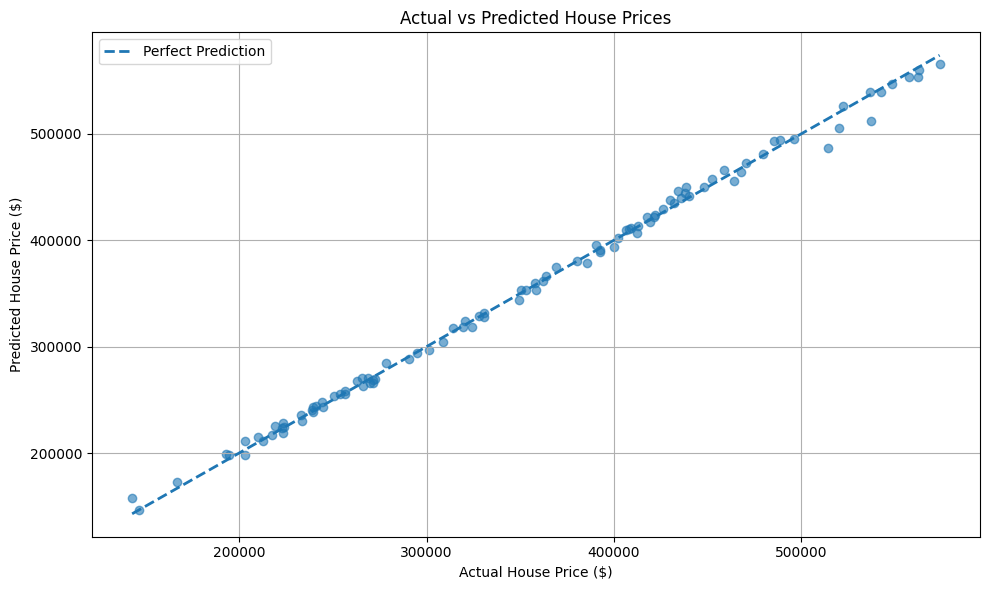

Prediction Statistics
Mean Absolute Error (MAE) : $4,302.27
Root Mean Squared Error   : $6,044.46
Average House Price       : $353,268.81


In [26]:
# ============================================================
# Step 10A – Visualize Predictions vs Actual Prices
# ============================================================
# A scatter plot allows us to visually compare the model's
# predictions against the true house prices.
#
# Points close to the diagonal line indicate accurate
# predictions.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- convert back to real prices ----------
y_test_real = scaler_y.inverse_transform(
    y_test.cpu().numpy()
)

y_pred_real = scaler_y.inverse_transform(
    y_pred.cpu().numpy()
)

# ---------- scatter plot ----------
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.6
)

# perfect prediction line
min_val = min(
    y_test_real.min(),
    y_pred_real.min()
)

max_val = max(
    y_test_real.max(),
    y_pred_real.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price ($)")
plt.ylabel("Predicted House Price ($)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------- prediction statistics ----------
errors = y_test_real - y_pred_real

mae = np.abs(errors).mean()

rmse = np.sqrt(
    (errors ** 2).mean()
)

print("Prediction Statistics")
print("=" * 55)

print(f"Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"Root Mean Squared Error   : ${rmse:,.2f}")
print(f"Average House Price       : ${y_test_real.mean():,.2f}")

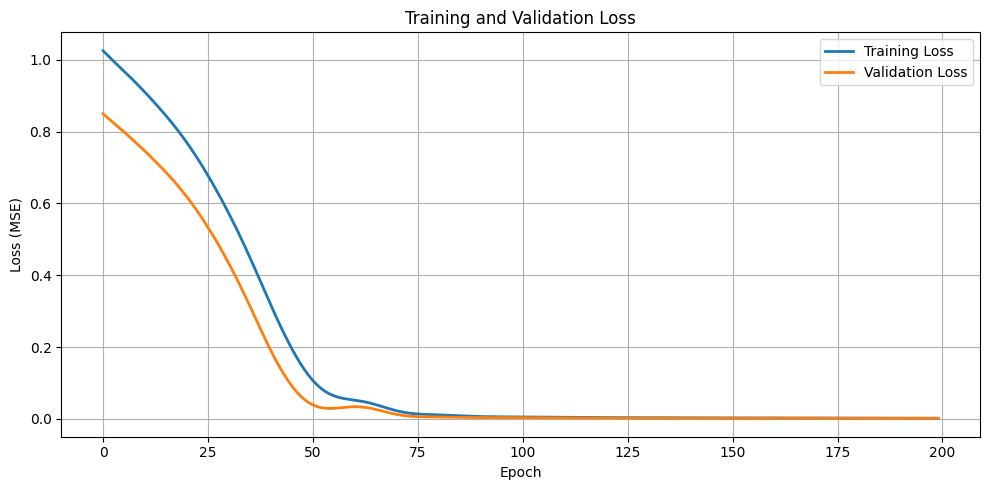

In [27]:
# ============================================================
# Step 10B – Visualize Training and Validation Loss
# ============================================================
# Training loss shows how well the model fits the training
# data, while validation loss shows how well it generalizes
# to unseen data.
#
# Ideally, both curves should decrease and stabilize over
# time.
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 11: Save the Trained Model

After investing time and computational resources in training our model, it's crucial to **save it for future use**.

**Why Save Models?**
- **Reusability**: Use the trained model without retraining
- **Deployment**: Deploy to production environments
- **Sharing**: Share models with team members or clients
- **Versioning**: Keep track of different model versions
- **Time-saving**: Avoid lengthy retraining processes

**What Gets Saved?**
- **Model weights (parameters)**: All learned weights and biases
- **Model architecture**: Layer structure and connections
- **Optimizer state** (optional): Useful for resuming training

**Best Practices:**
- Save after achieving satisfactory performance
- Use descriptive filenames with version numbers
- Include metadata (training date, performance metrics)
- Store models in a dedicated directory

We'll use PyTorch's `torch.save()` function to save our model's state dictionary to a `.pth` file.

In [28]:
# ============================================
# Step 11: Save Model + Scalers + Config
# ============================================
import os
import torch
import joblib

# ---- 1. Save model weights ----
model_path = "house_price_model.pth"
torch.save(model.state_dict(), model_path)

# ---- 2. Save both scalers ----
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

# ---- 3. Save full config bundle ----
config = {
    "model_state_dict": model.state_dict(),
    "input_size": input_size,
    "hidden_layers": [64, 32, 16],
    "output_size": 1,
    "epochs": EPOCHS,
    "learning_rate": optimizer.param_groups[0]['lr'],
    "feature_names": feature_names,
    "final_train_loss": train_losses[-1],
    "r2_score": r2,
    "test_mse": test_loss.item(),
}
bundle_path = "model_bundle.pth"
torch.save(config, bundle_path)

# ============================================
# Print Save Confirmation
# ============================================
print(" All artifacts saved successfully!")
print("=" * 55)
print(f" Model weights    : {model_path} ({os.path.getsize(model_path)/1024:.2f} KB)")
print(f" Feature scaler   : scaler_X.pkl ({os.path.getsize('scaler_X.pkl')/1024:.2f} KB)")
print(f" Target scaler    : scaler_y.pkl ({os.path.getsize('scaler_y.pkl')/1024:.2f} KB)")
print(f" Full bundle      : {bundle_path} ({os.path.getsize(bundle_path)/1024:.2f} KB)")

print("\n Model Information:")
print(f"   - Architecture    : {input_size} → 64 → 32 → 16 → 1")
print(f"   - Training epochs : {EPOCHS}")
print(f"   - Final R² score  : {r2:.4f}")
print(f"   - Test MSE        : {test_loss.item():.2f}")
print(f"   - Features saved  : {len(feature_names)}")

print("\n Model is ready for deployment!")

# ============================================
# How to Load & Reproduce Predictions Later
# ============================================
# import torch, joblib
#
# # Step 1: Load the bundle
# bundle = torch.load("model_bundle.pth")
#
# # Step 2: Recreate architecture from saved config
# loaded_model = HousePriceModel(bundle["input_size"])
# loaded_model.load_state_dict(bundle["model_state_dict"])
# loaded_model.eval()
#
# # Step 3: Load both scalers
# scaler_X = joblib.load("scaler_X.pkl")
# scaler_y = joblib.load("scaler_y.pkl")
#
# # Step 4: Preprocess new data & predict
# new_data_scaled = scaler_X.transform(new_data_df)
# new_tensor = torch.FloatTensor(new_data_scaled)
# predicted_scaled = loaded_model(new_tensor)
#
# # Step 5: Convert back to real USD prices
# real_price = scaler_y.inverse_transform(predicted_scaled.detach().numpy())

 All artifacts saved successfully!
 Model weights    : house_price_model.pth (16.27 KB)
 Feature scaler   : scaler_X.pkl (0.79 KB)
 Target scaler    : scaler_y.pkl (0.61 KB)
 Full bundle      : model_bundle.pth (16.58 KB)

 Model Information:
   - Architecture    : 8 → 64 → 32 → 16 → 1
   - Training epochs : 200
   - Final R² score  : 0.9970
   - Test MSE        : 0.00
   - Features saved  : 8

 Model is ready for deployment!


## Step 12: Load Model and Make Predictions on New Data

Now let's demonstrate how to **load the saved model** and use it for inference on new, unseen data.

**Loading Process:**
1. **Recreate the model architecture**: Instantiate the same model class
2. **Load saved weights**: Use `model.load_state_dict()`
3. **Set to evaluation mode**: Call `model.eval()` to disable dropout/batch norm

**Making Predictions:**
- Prepare new data in the **same format** as training data
- Apply the **same preprocessing** (one-hot encoding, normalization)
- Convert to PyTorch tensors
- Pass through the model

**Real-World Deployment Considerations:**
- **Input validation**: Ensure features are within expected ranges
- **Error handling**: Handle missing or invalid data gracefully
- **Preprocessing pipeline**: Save and load the scaler with the model
- **API integration**: Wrap predictions in REST API for web applications
- **Monitoring**: Track prediction quality in production
- **Model updates**: Periodically retrain with new data

Let's load our model and predict prices for some example houses!

In [29]:
# ============================================
# Step 12: Load Model and Make Predictions
# ============================================
import numpy as np
import torch
import joblib

# ============================================
# PART 1: Load the Saved Model & Scalers
# ============================================
loaded_model = HousePriceModel(input_size)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

# Load both scalers
scaler_X = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")

print(" Model & scalers loaded successfully!")
print("=" * 50)
print()

# ============================================
# PART 2: Define New Houses to Predict
# ============================================
new_houses = [
    {
        "square_feet": 2500,
        "crime_rate": 3.5,
        "school_quality": 8,
        "bedrooms": 4,
        "market_demand": "high",
        "renovated": 1,
        "description": "Luxury renovated family home in safe neighborhood"
    },
    {
        "square_feet": 1500,
        "crime_rate": 6.2,
        "school_quality": 5,
        "bedrooms": 2,
        "market_demand": "medium",
        "renovated": 0,
        "description": "Cozy starter home, needs some updates"
    },
    {
        "square_feet": 3200,
        "crime_rate": 2.1,
        "school_quality": 9,
        "bedrooms": 5,
        "market_demand": "high",
        "renovated": 1,
        "description": "Premium estate with top-rated schools nearby"
    }
]

print("\n Making predictions for new houses...\n")

# ============================================
# PART 3: Process Each House & Predict
# ============================================
for i, house in enumerate(new_houses, 1):

    # ---- Step A: Build the feature vector ----
    features = [
        house["square_feet"],
        house["crime_rate"],
        house["school_quality"],
        house["bedrooms"],
        house["renovated"],
        1 if house["market_demand"] == "high"   else 0,
        1 if house["market_demand"] == "low"    else 0,
        1 if house["market_demand"] == "medium" else 0
    ]

    # ---- Step B: Normalize features using scaler_X ----
    features_array = np.array(features).reshape(1, -1)
    features_normalized = scaler_X.transform(features_array)

    # ---- Step C: Convert to PyTorch tensor ----
    features_tensor = torch.FloatTensor(features_normalized)

    # ---- Step D: Predict & inverse transform to real USD ----
    with torch.no_grad():
        predicted_scaled = loaded_model(features_tensor).numpy()
        predicted_price = scaler_y.inverse_transform(predicted_scaled)[0][0]

    # ---- Step E: Display results ----
    print(f"{'='*70}")
    print(f" House #{i}: {house['description']}")
    print(f"{'='*70}")
    print(f" Square Feet:      {house['square_feet']:,} sq ft")
    print(f" Crime Rate:       {house['crime_rate']:.1f}/10")
    print(f" School Quality:   {house['school_quality']}/10")
    print(f" Bedrooms:         {house['bedrooms']}")
    print(f" Market Demand:    {house['market_demand'].capitalize()}")
    print(f" Renovated:        {'Yes' if house['renovated'] else 'No'}")
    print(f"\n Predicted Price:  ${predicted_price:,.2f}")
    print()

print("\n All predictions completed successfully!")

 Model & scalers loaded successfully!


 Making predictions for new houses...

 House #1: Luxury renovated family home in safe neighborhood
 Square Feet:      2,500 sq ft
 Crime Rate:       3.5/10
 School Quality:   8/10
 Bedrooms:         4
 Market Demand:    High
 Renovated:        Yes

 Predicted Price:  $449,086.06

 House #2: Cozy starter home, needs some updates
 Square Feet:      1,500 sq ft
 Crime Rate:       6.2/10
 School Quality:   5/10
 Bedrooms:         2
 Market Demand:    Medium
 Renovated:        No

 Predicted Price:  $217,414.91

 House #3: Premium estate with top-rated schools nearby
 Square Feet:      3,200 sq ft
 Crime Rate:       2.1/10
 School Quality:   9/10
 Bedrooms:         5
 Market Demand:    High
 Renovated:        Yes

 Predicted Price:  $535,828.44


 All predictions completed successfully!


# Conclusion: Complete Deep Learning Workflow

Congratulations! You've successfully completed an **end-to-end deep learning project** for house price prediction — from raw data all the way to deployment-ready inference. Here's a full recap of everything you built.

---

## Key Achievements

### 1. Data Generation & Management

We created a **synthetic dataset of 1,000 houses** with realistic, meaningful features and a domain-driven pricing formula.

| Feature | Type | Role in Pricing |
|:---|:---|:---|
| Square Footage | Numeric | Primary price driver |
| Crime Rate | Numeric | Negative impact on price |
| School Quality | Numeric (1–10) | Positive impact on price |
| Bedrooms | Numeric | Moderate positive impact |
| Market Demand | Categorical | Multiplier (low / medium / high) |
| Renovated | Binary (0/1) | Price boost when renovated |

---

### 2. Data Preprocessing Pipeline

Raw data went through four transformation stages before the model ever saw it:

| Step | Transformation | What It Did |
|:---|:---|:---|
| 1 | **One-Hot Encoding** | Split "market_demand" into 3 binary columns |
| 2 | **Train-Test Split** | 80% training / 20% testing |
| 3 | **StandardScaler** | Normalized all features to mean=0, std=1 |
| 4 | **Tensor Conversion** | Converted NumPy arrays to PyTorch FloatTensors |

---

### 3. Neural Network Architecture

A 4-layer feedforward neural network designed for regression:

| Layer | Operation | Output Shape |
|:-----:|:---------:|:------------:|
| **Input** | 8 Features | (batch, 8) |
| ↓ | | |
| **Hidden 1** | Linear(8 → 64) + ReLU | (batch, 64) |
| ↓ | | |
| **Hidden 2** | Linear(64 → 32) + ReLU | (batch, 32) |
| ↓ | | |
| **Hidden 3** | Linear(32 → 16) + ReLU | (batch, 16) |
| ↓ | | |
| **Output** | Linear(16 → 1) | (batch, 1) → Predicted Price |

| Detail | Value |
|:---|:---|
| Activation Function | ReLU (hidden layers) |
| Output Activation | None (raw regression output) |
| Total Trainable Parameters | ~5,000+ |

---

### 4. Model Training & Optimization

| Setting | Value |
|:---|:---|
| Epochs | 200 |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Loss Function | Mean Squared Error (MSE) |
| Convergence | Smooth, steadily decreasing loss |

---

### 5. Evaluation & Validation

We assessed model quality using both **metrics** and **visualizations**:

| Metric / Visual | Purpose |
|:---|:---|
| **R² Score** | How much variance the model explains (closer to 1 = better) |
| **MAE** | Average prediction error in dollars |
| **RMSE** | Average error, penalizing large misses |
| **Loss Curve** | Confirms training converged smoothly |
| **Scatter Plot** | Visual comparison of predicted vs actual prices |

---

### 6. Model Persistence & Deployment

Saved the trained weights to disk and demonstrated the full reload → predict cycle:

> **Save:** `torch.save(model.state_dict(), "house_price_model.pth")`
> ↓
> **Load:** Rebuild architecture → `load_state_dict()` → `.eval()`
> ↓
> **Predict:** Normalize new data with same scaler → run through model → get price

---

## Potential Improvements

### Hyperparameter Tuning

| What to Try | Range / Ideas |
|:---|:---|
| Learning Rate | 0.0001 → 0.01 |
| Network Size | Deeper (more layers) or wider (more neurons) |
| Batch Size | Mini-batch training (32, 64, 128) |
| LR Scheduling | Decay learning rate over time |
| Regularization | Add Dropout layers (0.1 – 0.3) |

### Additional Features

| Feature | Why It Helps |
|:---|:---|
| Location (lat/lng) | Geography is the #1 real-world price factor |
| House Age | Older homes may depreciate |
| Property Tax Rate | Reflects neighborhood value |
| Distance to City Center | Proximity premium |
| Bathrooms / Lot Size / Garage | More detail = better predictions |
| Energy Efficiency Rating | Growing buyer priority |

### Advanced Techniques

| Technique | Benefit |
|:---|:---|
| Cross-Validation | More robust evaluation than a single split |
| Ensemble Methods | Combine multiple models for better accuracy |
| Feature Engineering | Interaction terms, polynomial features |
| Batch Normalization | Faster, more stable training |
| Early Stopping | Automatically prevents overfitting |
| Bayesian Optimization | Smarter hyperparameter search |

### Data Enhancements

| Enhancement | Impact |
|:---|:---|
| Real-world datasets | True patterns, not synthetic |
| Outlier handling | Removes noise from extreme values |
| Missing value strategies | Makes pipeline production-ready |
| Time-series market trends | Captures price changes over time |

---

## Next Steps for Production Deployment

### 1. API Development

# Example: Flask API endpoint for predictions
@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    prediction = model.predict(preprocess(data))
    return jsonify({'price': prediction})

### 2. Containerization

Package the model, scaler, and dependencies into a **Docker container** for consistent deployment across cloud platforms (AWS, GCP, Azure).

### 3. Monitoring & Maintenance

| Task | Why It Matters |
|:---|:---|
| Track prediction accuracy over time | Detect model drift early |
| Implement logging | Debug issues in production |
| Set up anomaly alerts | Catch wildly wrong predictions |
| Schedule periodic retraining | Keep the model fresh with new data |

### 4. User Interface

Build a **web app** where users can input house features and instantly receive a price prediction — complete with input validation, error handling, and visualization dashboards.

---

## Final Thoughts

You've built a **complete machine learning pipeline from scratch** — data creation, preprocessing, model design, training, evaluation, saving, loading, and inference.

The key from here is **practice and experimentation.** Try changing the architecture, adding new features, swapping in real-world datasets, and exploring additional metrics. Every tweak teaches you something new.

> *Happy coding and best of luck with your deep learning journey!*